In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import pandas as pd
from sklearn.metrics import accuracy_score

In [8]:

train_img_path_lst = []
train_labels_list = []

val_img_path_lst = []
val_labels_list = []

test_img_paths = []
test_labels_list = []


train_df = pd.read_csv("/content/drive/MyDrive/Skin Disease Dataset/training split/skin disease encoded - Benchmark Train.csv")

val_df = pd.read_csv("/content/drive/MyDrive/Skin Disease Dataset/training split/skin disease encoded - Benchmark Val.csv")

test_df = pd.read_csv("/content/drive/MyDrive/Skin Disease Dataset/training split/skin disease encoded - Benchmark Test.csv")



for idx, row in train_df.iterrows():
    train_img_path_lst.append("/content/drive/MyDrive/Skin Disease Dataset/training split/benchmark images/" + row['image'])
    train_labels_list.append([row['Modality/ Type of image : q0'],
                            row['disease name/diagnosis : q1']])


for idx, row in val_df.iterrows():
    val_img_path_lst.append("/content/drive/MyDrive/Skin Disease Dataset/training split/benchmark images/" + row['image'])
    val_labels_list.append([row['Modality/ Type of image : q0'],
                            row['disease name/diagnosis : q1']])



for idx, row in test_df.iterrows():
    test_img_paths.append("/content/drive/MyDrive/Skin Disease Dataset/training split/benchmark images/" + row['image'])
    test_labels_list.append([row['Modality/ Type of image : q0'],
                        row['disease name/diagnosis : q1']])




print("-------------train----------------")
for itm in train_img_path_lst:
  print(itm)

for lable in train_labels_list:
  print(lable)

print("-------------val--------------------")
for itm in val_img_path_lst:
  print(itm)

for lable in val_labels_list:
  print(lable)

print("-------------test--------------------")
for itm in test_img_paths:
  print(itm)

for lable in test_labels_list:
  print(lable)

-------------train----------------
/content/drive/MyDrive/Skin Disease Dataset/training split/benchmark images/56dfc453-0d5e-41c1-83ea-9052d080681b.jpg
/content/drive/MyDrive/Skin Disease Dataset/training split/benchmark images/8ffd3247-76a4-4f90-8553-5e25cf18db27.jpg
/content/drive/MyDrive/Skin Disease Dataset/training split/benchmark images/3063992d-6a00-48c7-afc9-7ccd36f263be.jpg
/content/drive/MyDrive/Skin Disease Dataset/training split/benchmark images/77cd6c97-27f8-45da-ac39-f44c2fe9f751.jpg
/content/drive/MyDrive/Skin Disease Dataset/training split/benchmark images/091d873b-824e-4c03-9613-298b7b7a36f0.jpg
/content/drive/MyDrive/Skin Disease Dataset/training split/benchmark images/7a0136e2-7367-4af9-b4ee-96dbc5a4edc5.jpg
/content/drive/MyDrive/Skin Disease Dataset/training split/benchmark images/56744c69-08de-4383-9625-119ba6125080.jpg
/content/drive/MyDrive/Skin Disease Dataset/training split/benchmark images/941b67cf-38e9-442a-b7fa-ef0a9e383cb6.jpg
/content/drive/MyDrive/Skin D

In [9]:

# === Define your Multi-Head Model ===
class MultiHeadViT(nn.Module):
    def __init__(self, model_name, num_labels_list):
        super(MultiHeadViT, self).__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden_size = self.backbone.config.hidden_size
        self.heads = nn.ModuleList([
            nn.Linear(hidden_size, num_labels) for num_labels in num_labels_list
        ])

    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values=pixel_values)
        cls_token = outputs.last_hidden_state[:, 0, :]
        logits = [head(cls_token) for head in self.heads]
        return logits

# === Dummy Dataset ===
class DummyDataset(Dataset):
    def __init__(self, image_paths, labels_list, processor):
        self.image_paths = image_paths
        self.labels_list = labels_list
        self.processor = processor

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        inputs = self.processor(images=image, return_tensors="pt")

        labels = [torch.tensor(x) for x in self.labels_list[idx]]  # FIXED

        return {
            'pixel_values': inputs['pixel_values'].squeeze(0),
            'labels': labels
        }


# === Instantiate everything ===
vis_model_name = "google/vit-base-patch16-224"
num_labels_list = [4, 5]

vis_model = MultiHeadViT(vis_model_name, num_labels_list)

processor = AutoImageProcessor.from_pretrained(vis_model_name, use_fast=True)


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
print(vis_model.backbone.config.patch_size,
      vis_model.backbone.config.image_size,
      vis_model.backbone.config.hidden_dropout_prob,
      vis_model.backbone.config.attention_probs_dropout_prob,
      vis_model.backbone.config.hidden_act,
      vis_model.backbone.config.layer_norm_eps
)

16 224 0.0 0.0 gelu 1e-12


In [11]:
vis_model.backbone.config.patch_size = 32  #keep in the 2^n(power of 2) format. ex : 16, 32.
vis_model.backbone.config.image_size = 224
vis_model.backbone.config.hidden_dropout_prob = 0.0
vis_model.backbone.config.attention_probs_dropout_prob = 0.0
vis_model.backbone.config.hidden_act = "gelu"
vis_model.backbone.config.layer_norm_eps = 2e-6  #smaller the better

epoch_size = 20
Batch_Sz = 4   #<---Batch Size

# Loss and optimizer

criterions = [nn.CrossEntropyLoss() for _ in num_labels_list]  # One loss per head

#optimizer = optim.Adam(vis_model.parameters(), lr=2e-5)                         #
optimizer = optim.AdamW(vis_model.parameters(), lr=2e-6, weight_decay=0.01)     #--->pick only one optimizer and change the learning rate
#optimizer = optim.Adagrad(vis_model.parameters(), lr=0.01)                    #--->and weight decay(if applicable) there directly
#optimizer = optim.RMSprop(vis_model.parameters(), lr=0.01)                    # p.s. if reducing lr, increase epoch


'''
For lr and layer_norm_eps:
popular values are 2e-5, 1e-12 but try more
'''

'\nFor lr and layer_norm_eps:\npopular values are 2e-5, 1e-12 but try more\n'

In [12]:
print(vis_model.backbone.config.patch_size,
      vis_model.backbone.config.image_size,
      vis_model.backbone.config.hidden_dropout_prob,
      vis_model.backbone.config.attention_probs_dropout_prob,
      vis_model.backbone.config.hidden_act,
      vis_model.backbone.config.layer_norm_eps
)

32 224 0.0 0.0 gelu 2e-06


In [13]:

train_dataset = DummyDataset(train_img_path_lst, train_labels_list, processor)
train_dataloader = DataLoader(train_dataset, batch_size=Batch_Sz, shuffle=True)

val_dataset = DummyDataset(val_img_path_lst, val_labels_list, processor)
val_dataloader = DataLoader(val_dataset, batch_size=Batch_Sz, shuffle=False)

test_dataset = DummyDataset(test_img_paths, test_labels_list, processor)
test_dataloader = DataLoader(test_dataset, batch_size=Batch_Sz, shuffle=False)


In [14]:
# === Training loop ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vis_model.to(device)

MultiHeadViT(
  (backbone): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermediate_act

In [15]:

for epoch in range(epoch_size):
    vis_model.train()
    total_loss = 0
    correct_preds = [0] * len(num_labels_list)
    total_preds = [0] * len(num_labels_list)

    for batch in train_dataloader:
        pixel_values = batch['pixel_values'].to(device)
        labels = [label.to(device) for label in batch['labels']]

        optimizer.zero_grad()
        logits_list = vis_model(pixel_values)

        losses = []
        for i, (logits, label, criterion) in enumerate(zip(logits_list, labels, criterions)):
            loss = criterion(logits, label)
            losses.append(loss)

            preds = torch.argmax(logits, dim=1)
            correct_preds[i] += (preds == label).sum().item()
            total_preds[i] += label.size(0)

        loss = sum(losses)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} - Training Loss: {total_loss:.4f}")
    for i in range(len(num_labels_list)):
        acc = correct_preds[i] / total_preds[i] if total_preds[i] > 0 else 0
        print(f"  Train Task {i+1} Accuracy: {acc * 100:.2f}%")

    # === Validation after each epoch ===
    vis_model.eval()
    val_loss = 0
    val_correct_preds = [0] * len(num_labels_list)
    val_total_preds = [0] * len(num_labels_list)

    with torch.no_grad():
        for batch in val_dataloader:
            pixel_values = batch['pixel_values'].to(device)
            labels = [label.to(device) for label in batch['labels']]
            logits_list = vis_model(pixel_values)

            losses = []
            for i, (logits, label, criterion) in enumerate(zip(logits_list, labels, criterions)):
                loss = criterion(logits, label)
                losses.append(loss)

                preds = torch.argmax(logits, dim=1)
                val_correct_preds[i] += (preds == label).sum().item()
                val_total_preds[i] += label.size(0)

            val_loss += sum(losses).item()

    print(f"          Validation Loss: {val_loss:.4f}")
    for i in range(len(num_labels_list)):
        acc = val_correct_preds[i] / val_total_preds[i] if val_total_preds[i] > 0 else 0
        print(f"  Val Task {i+1} Accuracy: {acc * 100:.2f}%")


Epoch 1 - Training Loss: 366.8406
  Train Task 1 Accuracy: 41.94%
  Train Task 2 Accuracy: 52.63%
          Validation Loss: 35.8191
  Val Task 1 Accuracy: 48.65%
  Val Task 2 Accuracy: 67.57%
Epoch 2 - Training Loss: 265.4502
  Train Task 1 Accuracy: 57.05%
  Train Task 2 Accuracy: 75.72%
          Validation Loss: 28.6561
  Val Task 1 Accuracy: 63.51%
  Val Task 2 Accuracy: 82.43%
Epoch 3 - Training Loss: 225.6905
  Train Task 1 Accuracy: 63.50%
  Train Task 2 Accuracy: 80.48%
          Validation Loss: 25.2324
  Val Task 1 Accuracy: 70.27%
  Val Task 2 Accuracy: 85.14%
Epoch 4 - Training Loss: 201.3161
  Train Task 1 Accuracy: 69.27%
  Train Task 2 Accuracy: 81.83%
          Validation Loss: 23.3214
  Val Task 1 Accuracy: 75.68%
  Val Task 2 Accuracy: 87.84%
Epoch 5 - Training Loss: 183.2018
  Train Task 1 Accuracy: 73.68%
  Train Task 2 Accuracy: 84.55%
          Validation Loss: 22.1609
  Val Task 1 Accuracy: 75.68%
  Val Task 2 Accuracy: 89.19%
Epoch 6 - Training Loss: 166.6502
 

In [16]:
def evaluate_model(model, dataloader, num_labels_list, device):
    model.eval()
    correct_preds = [0] * len(num_labels_list)
    total_preds = [0] * len(num_labels_list)

    with torch.no_grad():
        for batch in dataloader:
            pixel_values = batch['pixel_values'].to(device)
            labels = [label.to(device) for label in batch['labels']]

            logits_list = model(pixel_values)

            for i, (logits, label) in enumerate(zip(logits_list, labels)):
                preds = torch.argmax(logits, dim=1)
                correct_preds[i] += (preds == label).sum().item()
                total_preds[i] += label.size(0)

    accuracies = [correct / total * 100 if total > 0 else 0.0
                  for correct, total in zip(correct_preds, total_preds)]
    return accuracies


test_accuracies = evaluate_model(vis_model, test_dataloader, num_labels_list, device)

print("\n=== Test Set Accuracy ===")
for i, acc in enumerate(test_accuracies):
    print(f"Task {i+1} Accuracy: {acc:.2f}%")



=== Test Set Accuracy ===
Task 1 Accuracy: 56.76%
Task 2 Accuracy: 77.03%


In [ ]:
from PIL import Image
import torch

# === Set model to evaluation mode ===
vis_model.eval()

def vis_preds(img_path):

  # === Load and preprocess your image ===
  #img_path = "/content/drive/MyDrive/Skin Disease Dataset/dummy dataset/lab_pred.jpg"  # Your new image
  image = Image.open(img_path).convert("RGB")
  inputs = processor(images=image, return_tensors="pt")

  # === Move input to device (GPU/CPU) ===
  pixel_values = inputs['pixel_values'].to(device)

  # === Get model output ===
  with torch.no_grad():  # No gradient computation needed during inference
      logits_list = vis_model(pixel_values)

  # === Interpret outputs ===
  preds = []
  for logits in logits_list:
      pred_class = torch.argmax(logits, dim=-1)  # Take max logit for each head
      preds.append(pred_class.item())  # Convert to Python int

  return preds


Predicted classes: [0, 1, 2, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:

#img_path = '/content/drive/MyDrive/Skin Disease Dataset/training split/combined-img/ISIC_7615896.jpg' #0	1	2	0	0	1	0	0	0	0	0	0	0	0	0
#img_path = '/content/drive/MyDrive/Skin Disease Dataset/training split/combined-img/84_VI-chickenpox (7).jpg' # 1	0	0	2	1	0	0	0	0	0	0	0	0	1	1
img_path = '/content/drive/MyDrive/Skin Disease Dataset/training split/combined-img/ISIC_7623089.jpg'  # 0	1	2	0	0	1	1	0	0	0	0	0	0	0	0

print("Predicted classes:", vis_preds(img_path))

In [ ]:
torch.save(vis_model, "multihead_vit_model_full.pt")
processor.save_pretrained("./vit_processor")


In [ ]:
# Re-initialize the model
loaded_model = MultiHeadViT(model_name=vis_model_name, num_labels_list=num_labels_list)
loaded_model.load_state_dict(torch.load("multihead_vit_model.pth"))
loaded_model.to(device)
loaded_model.eval()


In [ ]:
def vis_preds(img_path):

  # === Load and preprocess your image ===
  #img_path = "/content/drive/MyDrive/Skin Disease Dataset/dummy dataset/lab_pred.jpg"  # Your new image
  image = Image.open(img_path).convert("RGB")
  inputs = processor(images=image, return_tensors="pt")

  # === Move input to device (GPU/CPU) ===
  pixel_values = inputs['pixel_values'].to(device)

  # === Get model output ===
  with torch.no_grad():  # No gradient computation needed during inference
      logits_list = vis_model(pixel_values)

  # === Interpret outputs ===
  preds = []
  for logits in logits_list:
      pred_class = torch.argmax(logits, dim=-1)  # Take max logit for each head
      preds.append(pred_class.item())  # Convert to Python int

  return preds

img_path = '/content/drive/MyDrive/Skin Disease Dataset/training split/combined-img/ISIC_7623407.jpg'  # Your new image

print("Predicted classes:", vis_preds(img_path))

Predicted classes: [0, 1, 2, 0, 0]


In [ ]:
import json

# Load JSON file
with open('/content/drive/MyDrive/Skin Disease Dataset/training split/train.json', 'r') as f:
    json_questions = json.load(f)

# Now `data` is a Python dictionary or list depending on the JSON content
print(json_questions[0]["question"])


What is the name for this disease?


In [ ]:
#text dataset preprocessing


import random

questions=[]
answers=[]

added_question = ["Is the disease contagious?",
                  "Is it contagious?",
                  "What is the probability that this is contagious?",
                  "What is the probability that this disease is contagious?",
                  "What are the probability that this is contagious?",
                  "Is it contagious or not?"
                  ]


for i in range(0, len(json_questions), 7):
  questions.append(json_questions[0]["question"])
  questions.append(json_questions[1]["question"])
  questions.append(json_questions[2]["question"])
  questions.append(json_questions[3]["question"])
  questions.append(json_questions[4]["question"])
  questions.append(json_questions[5]["question"])
  questions.append(json_questions[6]["question"])
  questions.append(random.choice(added_question))
  answers.append("name")
  answers.append("cancerous")
  answers.append("features")
  answers.append("severity")
  answers.append("preventions")
  answers.append("test")
  answers.append("cause")
  answers.append("contagious")

In [ ]:
print(f"JSON Question len:{len(json_questions)}\nQuestion len:{len(questions)}\nAnswer len:{len(answers)}")

JSON Question len:4235
Question len:4840
Answer len:4840


In [ ]:
print(len(questions)/7)

691.4285714285714


In [ ]:
for i in range(16):
  print(questions[i])
  print(answers[i], "\n")

What is the name for this disease?
name 

Is it cancerous or benign?
cancerous 

What are the visible features in this image which indicates the disease?
features 

What is the severity of this disease?
severity 

What are the preventive measures for this disease?
preventions 

What diagnostic tests are recommended?
test 

What is the cause of this disease?
cause 

Is it contagious?
contagious 

What is the name for this disease?
name 

Is it cancerous or benign?
cancerous 

What are the visible features in this image which indicates the disease?
features 

What is the severity of this disease?
severity 

What are the preventive measures for this disease?
preventions 

What diagnostic tests are recommended?
test 

What is the cause of this disease?
cause 

What is the probability that this is contagious?
contagious 



**LSTM** model

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder



# Encode labels (answers)
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(answers)

# Tokenize questions
tokenizer = Tokenizer(num_words=1000, oov_token="<OOV>")
tokenizer.fit_on_texts(questions)
sequences = tokenizer.texts_to_sequences(questions)
padded = pad_sequences(sequences, maxlen=10, padding='post')

# Build LSTM model
text_model = Sequential([
    Embedding(input_dim=1000, output_dim=64, input_length=10),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(len(set(labels)), activation='softmax')  # Output = number of unique answers
])

text_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train model
text_model.fit(padded, np.array(labels), epochs=7)

# Prediction function
def predict_answer(question):
    seq = tokenizer.texts_to_sequences([question])
    pad = pad_sequences(seq, maxlen=10, padding='post')
    pred = np.argmax(text_model.predict(pad), axis=-1)
    return label_encoder.inverse_transform(pred)[0]

# Test
print("Prediction:", predict_answer("What are the preventive measures for this disease?"))


Epoch 1/7


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


152/152 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6370 - loss: 1.2485
Epoch 2/7
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 1.0000 - loss: 0.0035
Epoch 3/7
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 0.0012
Epoch 4/7
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 5.9731e-04
Epoch 5/7
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 3.7023e-04
Epoch 6/7
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 2.5380e-04
Epoch 7/7
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 1.8333e-04
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
Prediction: preventions


In [ ]:

# Test
print("Prediction:", predict_answer("What is the name for this disease?"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Prediction: name


In [ ]:
print(answers[0:8])

['name', 'cancerous', 'features', 'severity', 'preventions', 'test', 'cause', 'contagious']


In [ ]:
#not tested. better not to use yet

encode_lst={
            "name" : {0 : "melanoma", 1 : "chiken pox", 2 : "impetigo", 3 : "nail fungus/Onychomycosis", 4 : "ringworm", 5 : "shingles", 6 : "vascular lesion"},
            "cancerous" : {0 : "No", 1 : "Yes"},
            "severity" : {0 : "Mild", 1 : "Moderate", 2 : "Severe"},
            "cause" : {0 : "UV", 1 : "blood vessel abnormality", 2 : "varicella-zoster", 3 : "fungal", 4 : "bacterial", 5 : "reactivated varicella zoster"},
            "contagious" : {0 : "No", 1 : "Yes"},
            "diagnosis" : [
                           "Biopsy",
                           "Dermatioscopy",
                           "Imaging",
                           "Full Skin Examination",
                           "Blood test",
                           "Direct fluorescent antibody (DFA) test",
                           "Clinical evaluation",
                           "Serological tests",
                           "PCR test",
                           "Antigen detection test",
                           "KOH Test",
                           "Culture Test"
                           ],
            "preventions" : [
                             "Vaccine",
                             "Avoid UV rays",
                             "Maintain hygiene",
                             "Anitfungal Powder"
                             ]
            }


# encode_lst={
#             "name" : {0 : "melanoma", 1 : "chiken pox", 2 : "impetigo", 3 : "nail fungus/Onychomycosis", 4 : "ringworm", 5 : "shingles", 6 : "vascular lesion"},
#             "cancerous" : {0 : "No", 1 : "Yes"},
#             "severity" : {0 : "Mild", 1 : "Moderate", 2 : "Severe"},
#             "cause" : {0 : "UV", 1 : "blood vessel abnorm", 2 : "varicella-zoster", 3 : "fungal", 4 : "bacterial", 5 : "reactivated varicella zoster"},
#             "contagious" : {0 : "No", 0 : "Yes"},
#             "features" : "N/A",
#             "preventions" : "N/A",
#             "test" : "N/A"
#             }



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


<ipython-input-20-1bd281d09df8>:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(I)


What is the cause of the disease? 

Report:name
Encode lst:vascular lesion

Report:cancerous
Encode lst:Yes

Report:severity
Encode lst:Mild

Report:cause
Encode lst:blood vessel abnormality

Report:contagious
Encode lst:No

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Answer :  blood vessel abnormality


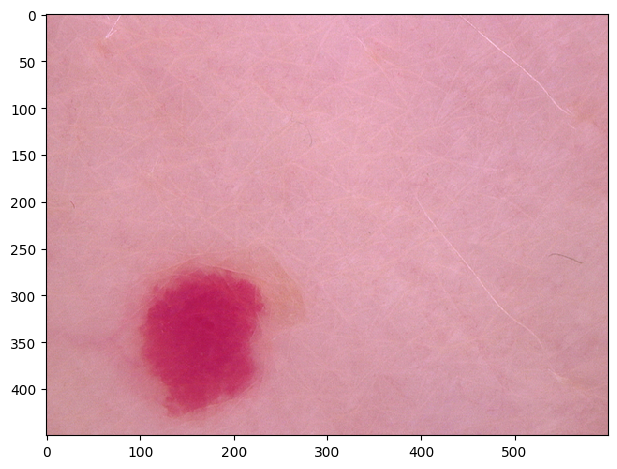

In [ ]:
from PIL import Image
import io
from skimage import io, transform, img_as_float


def merge(img_path, ques):
  I = io.imread(img_path)
  io.imshow(I)

  preds = vis_preds(img_path)
  txt_preds = predict_answer(ques)

  #print(preds)
  #print(ques, txt_preds, "\n")
  print(ques, "\n")

  report = {"name" : None,
            "cancerous" : None,
            "severity" : None,
            "cause" : None,
            "contagious" : None,
            }
  keys = list(report)

  for i in range(len(preds)):
    print(f"Report:{keys[i]}\nEncode lst:{encode_lst[keys[i]][preds[i]]}\n")
    report[keys[i]] = encode_lst[keys[i]][preds[i]]

  return report[predict_answer(ques)]


img_path = "/content/drive/MyDrive/Skin Disease Dataset/training split/combined-img/ISIC_0025677.jpg"

print("Answer : ", merge(img_path, "What is the cause of the disease?"))

In [ ]:
import tensorflow as tf


In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(vis_model)
print(f"Total trainable parameters: {total_params}")


Total trainable parameters: 86404628


In [ ]:
text_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 10, 64)         │        64,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 298,106 (1.14 MB)

 Trainable params: 99,368 (388.16 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 198,738 (776.32 KB)

In [ ]:
questions = ["What type is the dog?",
             "What is the colour?",
             "What size is the dog?",
             "What species of dog is it?",
             "What colour is the dog?",
             "Tell the size of the dog",
             "What is the breed of this dog",
             "Tell the colour of this dog",
             "Determine the dog's size"]

answers = ["Q1", "Q2", "Q3", "Q1", "Q2", "Q3", "Q1", "Q2", "Q3"]  # Labels

# Encode answers as integers
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(answers)


In [ ]:

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [ ]:
# from keras.preprocessing.text import Tokenizer
# from keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(questions)
sequences = tokenizer.texts_to_sequences(questions)
padded_sequences = pad_sequences(sequences, maxlen=20, padding='post')


In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=10000, output_dim=64, input_length=20),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(len(label_encoder.classes_), activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(padded_sequences, labels, epochs=10, batch_size=16)


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3333 - loss: 1.0989
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.3333 - loss: 1.0986
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.3333 - loss: 1.0985
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3333 - loss: 1.0984
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.3333 - loss: 1.0982
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.3333 - loss: 1.0979
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.3333 - loss: 1.0977
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.3333 - loss: 1.0974
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.3333 - loss: 1.0970
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.3333 - loss: 1.0965


In [ ]:
import torch
import torch.nn as nn

class LSTMQuestionAnswering(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, num_layers=1):
        super(LSTMQuestionAnswering, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.embedding(x)              # (batch_size, seq_len, embed_dim)
        output, (hidden, cell) = self.lstm(x)
        out = self.fc(hidden[-1])           # (batch_size, output_dim)
        return out


In [ ]:
# Assume vocab size is 5000
model = LSTMQuestionAnswering(vocab_size=5000, embed_dim=128, hidden_dim=256, output_dim=5000)

# Dummy input: a batch of 2 questions, each 10 tokens long
dummy_input = torch.randint(0, 5000, (2, 10))  # (batch_size=2, seq_len=10)

# Forward pass
output = model(dummy_input)  # (batch_size=2, output_dim=5000)

# Get predicted word
predicted_word_ids = torch.argmax(output, dim=1)
print(predicted_word_ids)  # Predicted word indices


tensor([4180, 3534])


In [ ]:
def predict_question(question):
    seq = tokenizer.texts_to_sequences([question])
    padded = pad_sequences(seq, maxlen=20, padding='post')
    pred = model.predict(padded)
    label_index = pred.argmax()
    return label_encoder.inverse_transform([label_index])[0]

print(predict_question("What kind of dog is it?"))

print(predict_question("What is the colour of this dog?"))


AttributeError: 'LSTMQuestionAnswering' object has no attribute 'predict'

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from collections import Counter
import numpy as np

#=== Dummy Data ===
questions = ["What type is the dog?",
             "What is the colour?",
             "What size is the dog?",
             "What species of dog is it?",
             "What colour is the dog?",
             "Tell the size of the dog",
             "What is the breed of this dog",
             "Tell the colour of this dog",
             "Determine the dog's size"]

answers = ["Q1", "Q2", "Q3", "Q1", "Q2", "Q3", "Q1", "Q2", "Q3"]  # Labels

# questions = [
#     "Is the sky blue?",
#     "Can pigs fly?",
#     "Is water wet?",
#     "Do humans need oxygen?",
#     "Is fire cold?"
# ]

# answers = ["yes", "no", "yes", "yes", "no"]

# === Preprocessing ===
class Vocabulary:
    def __init__(self, min_freq=1):
        self.token2idx = {"<PAD>": 0, "<UNK>": 1}
        self.idx2token = ["<PAD>", "<UNK>"]
        self.min_freq = min_freq

    def build_vocab(self, texts):
        counter = Counter(token for text in texts for token in text.lower().split())
        for word, freq in counter.items():
            if freq >= self.min_freq:
                self.token2idx[word] = len(self.idx2token)
                self.idx2token.append(word)

    def encode(self, text):
        return [self.token2idx.get(token, 1) for token in text.lower().split()]

    def pad_sequence(self, seq, max_len):
        return seq + [0] * (max_len - len(seq))

# === Encode Labels ===
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(answers)

# === Create Dataset ===
class QuestionDataset(Dataset):
    def __init__(self, questions, labels, vocab, max_len):
        self.data = []
        for q, label in zip(questions, labels):
            encoded = vocab.encode(q)
            padded = vocab.pad_sequence(encoded, max_len)
            self.data.append((torch.tensor(padded), torch.tensor(label)))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# === LSTM Model ===
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        return self.fc(hidden.squeeze(0))

# === Setup ===
vocab = Vocabulary()
vocab.build_vocab(questions)
max_len = max(len(q.split()) for q in questions)

dataset = QuestionDataset(questions, encoded_labels, vocab, max_len)
train_loader = DataLoader(dataset, batch_size=2, shuffle=True)

model = LSTMClassifier(vocab_size=len(vocab.idx2token), embedding_dim=64, hidden_dim=128, output_dim=len(label_encoder.classes_))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# === Training Loop ===
for epoch in range(10):
    total_loss = 0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}: Loss = {total_loss:.4f}")

# === Inference ===
def predict(question):
    model.eval()
    encoded = vocab.encode(question)
    padded = vocab.pad_sequence(encoded, max_len)
    input_tensor = torch.tensor(padded).unsqueeze(0)
    with torch.no_grad():
        output = model(input_tensor)
        pred = torch.argmax(output, dim=1).item()
        return label_encoder.inverse_transform([pred])[0]

# === Test ===
# print(predict("Can dogs fly?"))   # Expected: "no"
# print(predict("Do fish swim?"))   # Expected: "yes"

print(predict("What kind of dog is it?"))            # Expected: "Q1"
print(predict("What is the colour of this dog?"))    # Expected: "Q2"

Epoch 1: Loss = 5.8829
Epoch 2: Loss = 5.3848
Epoch 3: Loss = 5.0584
Epoch 4: Loss = 4.8545
Epoch 5: Loss = 4.5438
Epoch 6: Loss = 4.2702
Epoch 7: Loss = 3.6919
Epoch 8: Loss = 2.8350
Epoch 9: Loss = 3.2572
Epoch 10: Loss = 1.7153
Q1
Q1
